# macro-supply-signals — Quickstart

This notebook walks through every public entry-point in the library:

1. **Setup** — API key and imports  
2. **Individual `get_*` functions** — one cell per signal family  
3. **The §5 output schema** — provenance columns every DataFrame carries  
4. **`fetch_signal` / catalog API** — pull by stable logical id  
5. **Combined view** — align monthly and daily signals for a macro snapshot

> **Prerequisite:** a free FRED API key at https://fred.stlouisfed.org/docs/api/api_key.html  
> Set it in a `.env` file at the project root: `FRED_API_KEY=your_key_here`

In [6]:
print("hello")


hello


## 1. Setup

In [7]:
# Standard library and third-party
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

START = "2010-01-01"  # change to narrow / widen the date window

## 2. Inflation signals

### 2a. CPI — Consumer Price Index (headline)

In [8]:
from macro_supply_signals.signals.inflation import get_cpi

cpi = get_cpi(start=START)
print(f"{len(cpi)} rows  |  {cpi['date'].min().date()} → {cpi['date'].max().date()}")
cpi.tail(6)

/Users/asthagupta/projects/macro-supply-signals/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


194 rows  |  2010-01-01 → 2026-03-01


,date,native_series_id,value,cpi_yoy,cpi_mom,signal_id,frequency,source
188,2025-09-01,CPIAUCSL,324.2450,3.0226,0.2951,inflation.cpi_headline,M,fred
189,2025-11-01,CPIAUCSL,325.0630,2.9883,0.2523,inflation.cpi_headline,M,fred
190,2025-12-01,CPIAUCSL,326.0310,3.0023,0.2978,inflation.cpi_headline,M,fred
191,2026-01-01,CPIAUCSL,326.5880,2.8287,0.1708,inflation.cpi_headline,M,fred
192,2026-02-01,CPIAUCSL,327.4600,2.6646,0.2670,inflation.cpi_headline,M,fred
193,2026-03-01,CPIAUCSL,330.2930,3.3202,0.8651,inflation.cpi_headline,M,fred


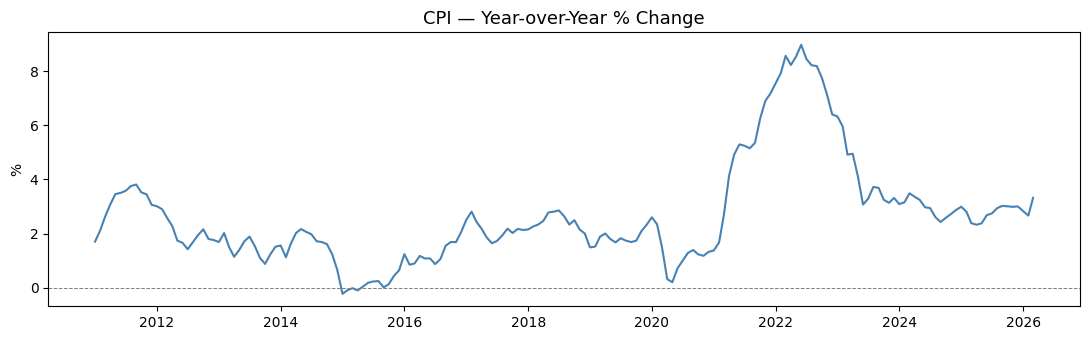

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(cpi["date"], cpi["cpi_yoy"], linewidth=1.5, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_title("CPI — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

### 2b. PPI — Producer Price Index (all commodities)

In [10]:
from macro_supply_signals.signals.ppi import get_ppi

ppi = get_ppi(start=START)
ppi.tail(6)

,date,native_series_id,value,ppi_yoy,ppi_mom,signal_id,frequency,source
189,2025-10-01,PPIACO,260.5910,2.9674,-0.5583,inflation.ppi_all_commodities,M,fred
190,2025-11-01,PPIACO,261.9140,3.4371,0.5077,inflation.ppi_all_commodities,M,fred
191,2025-12-01,PPIACO,261.3490,3.1276,-0.2157,inflation.ppi_all_commodities,M,fred
192,2026-01-01,PPIACO,263.4850,2.3799,0.8173,inflation.ppi_all_commodities,M,fred
193,2026-02-01,PPIACO,269.2960,3.7758,2.2054,inflation.ppi_all_commodities,M,fred
194,2026-03-01,PPIACO,274.1020,6.0253,1.7847,inflation.ppi_all_commodities,M,fred


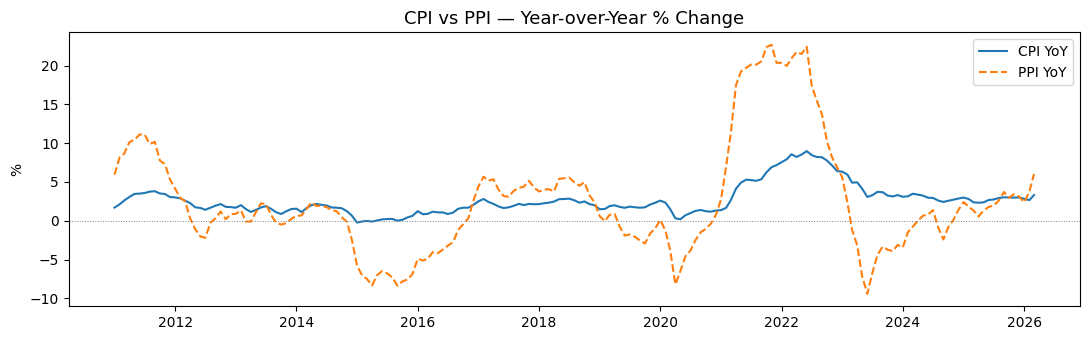

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(cpi["date"], cpi["cpi_yoy"], label="CPI YoY", linewidth=1.5)
ax.plot(ppi["date"], ppi["ppi_yoy"], label="PPI YoY", linewidth=1.5, linestyle="--")
ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
ax.set_title("CPI vs PPI — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 3. Activity — Industrial Production

In [12]:
from macro_supply_signals.signals.industrial import get_industrial_production

ip = get_industrial_production(start=START)
ip.tail(6)

,date,native_series_id,value,ip_yoy,ip_mom,signal_id,frequency,source
189,2025-10-01,INDPRO,101.2195,1.7593,-0.4411,activity.industrial_production,M,fred
190,2025-11-01,INDPRO,101.0810,1.8012,-0.1368,activity.industrial_production,M,fred
191,2025-12-01,INDPRO,101.6113,1.2798,0.5246,activity.industrial_production,M,fred
192,2026-01-01,INDPRO,101.5954,1.5297,-0.0156,activity.industrial_production,M,fred
193,2026-02-01,INDPRO,102.3440,1.2312,0.7368,activity.industrial_production,M,fred
194,2026-03-01,INDPRO,101.7898,0.7417,-0.5415,activity.industrial_production,M,fred


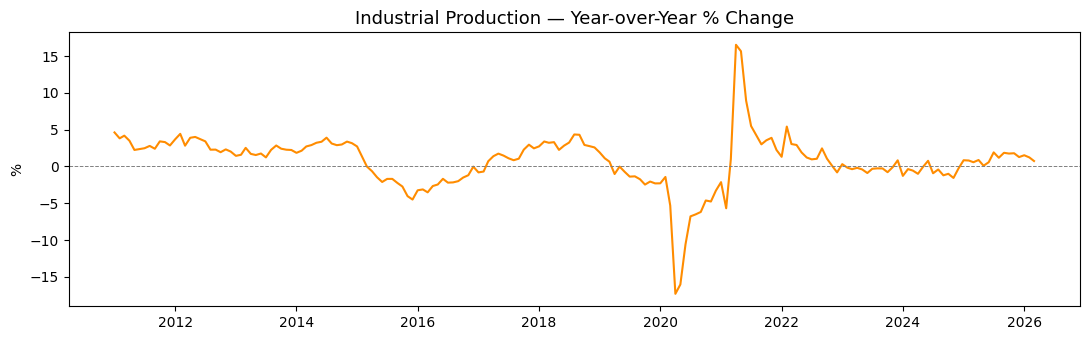

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ip["date"], ip["ip_yoy"], linewidth=1.5, color="darkorange")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_title("Industrial Production — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 4. Energy — WTI and Brent crude

In [14]:
from macro_supply_signals.signals.energy import get_wti, get_brent

wti   = get_wti(start=START)
brent = get_brent(start=START)

print("WTI:")
print(wti.tail(4).to_string(index=False))
print("\nBrent:")
print(brent.tail(4).to_string(index=False))

WTI:
      date native_series_id   value  chg_1d  chg_30d        signal_id frequency source
2026-04-22       DCOILWTICO 94.7600  1.1961  13.2003 energy.crude_wti         D   fred
2026-04-23       DCOILWTICO 99.2700  4.7594  14.3664 energy.crude_wti         D   fred
2026-04-24       DCOILWTICO 98.4200 -0.8563   2.9390 energy.crude_wti         D   fred
2026-04-27       DCOILWTICO 99.8900  1.4936   1.4318 energy.crude_wti         D   fred

Brent:
      date native_series_id    value  chg_1d  chg_30d          signal_id frequency source
2026-04-22     DCOILBRENTEU 113.4400  6.8777  20.2332 energy.crude_brent         D   fred
2026-04-23     DCOILBRENTEU 113.2500 -0.1675  26.0574 energy.crude_brent         D   fred
2026-04-24     DCOILBRENTEU 111.8600 -1.2274  22.9501 energy.crude_brent         D   fred
2026-04-27     DCOILBRENTEU 113.8900  1.8148  11.2424 energy.crude_brent         D   fred


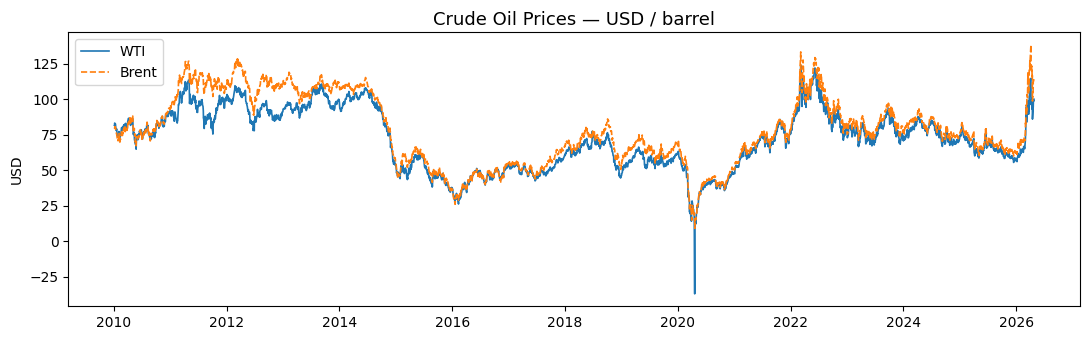

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(wti["date"],   wti["value"],   label="WTI",   linewidth=1.2)
ax.plot(brent["date"], brent["value"], label="Brent", linewidth=1.2, linestyle="--")
ax.set_title("Crude Oil Prices — USD / barrel", fontsize=13)
ax.set_ylabel("USD")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 5. FX — USD Broad Nominal Index

In [16]:
from macro_supply_signals.signals.fx import get_usd_index

usd = get_usd_index(start=START)
usd.tail(6)

,date,native_series_id,value,chg_1d,chg_30d,signal_id,frequency,source
4055,2026-04-17,DTWEXBGS,118.0795,-0.2383,-1.1813,fx.usd_broad_nominal,D,fred
4056,2026-04-20,DTWEXBGS,118.2374,0.1337,-1.0691,fx.usd_broad_nominal,D,fred
4057,2026-04-21,DTWEXBGS,118.4331,0.1655,-0.2463,fx.usd_broad_nominal,D,fred
4058,2026-04-22,DTWEXBGS,118.6004,0.1413,-0.5768,fx.usd_broad_nominal,D,fred
4059,2026-04-23,DTWEXBGS,118.7155,0.0970,-0.9240,fx.usd_broad_nominal,D,fred
4060,2026-04-24,DTWEXBGS,118.7294,0.0117,-1.5117,fx.usd_broad_nominal,D,fred


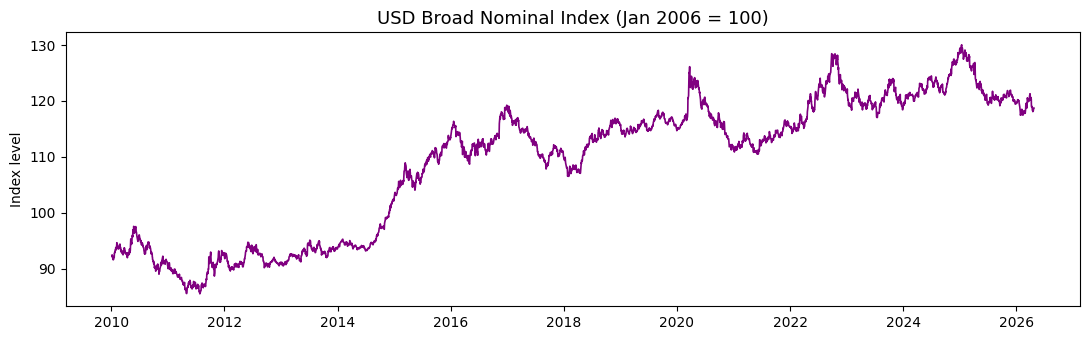

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(usd["date"], usd["value"], linewidth=1.2, color="purple")
ax.set_title("USD Broad Nominal Index (Jan 2006 = 100)", fontsize=13)
ax.set_ylabel("Index level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 6. The §5 output schema

Every DataFrame returned by a `get_*` function (or `fetch_signal`) carries the same provenance columns defined in §5 of the design doc:

| Column | Description |
|--------|-------------|
| `date` | Observation date |
| `signal_id` | Stable logical id, e.g. `inflation.cpi_headline` |
| `native_series_id` | Vendor series identifier, e.g. `CPIAUCSL` |
| `value` | Primary level for the signal |
| `frequency` | `D` (daily) or `M` (monthly) |
| `source` | Data provider — currently always `fred` |

In [18]:
SCHEMA_COLS = ["date", "signal_id", "native_series_id", "value", "frequency", "source"]

for name, df in [("CPI", cpi), ("PPI", ppi), ("IP", ip), ("WTI", wti), ("Brent", brent), ("USD", usd)]:
    missing = [c for c in SCHEMA_COLS if c not in df.columns]
    status  = "✓" if not missing else f"✗ missing {missing}"
    print(f"{name:6s}  {status}  signal_id={df['signal_id'].iloc[0]!r}  freq={df['frequency'].iloc[0]!r}")

CPI     ✓  signal_id='inflation.cpi_headline'  freq='M'
PPI     ✓  signal_id='inflation.ppi_all_commodities'  freq='M'
IP      ✓  signal_id='activity.industrial_production'  freq='M'
WTI     ✓  signal_id='energy.crude_wti'  freq='D'
Brent   ✓  signal_id='energy.crude_brent'  freq='D'
USD     ✓  signal_id='fx.usd_broad_nominal'  freq='D'


## 7. `fetch_signal` — pull by catalog id

All `get_*` functions are thin wrappers around `fetch_signal`. You can call it directly using the stable id constants from `catalog.py` — useful for batch tooling or a future client API.

In [19]:
from macro_supply_signals.catalog import (
    fetch_signal,
    INFLATION_CPI_HEADLINE,
    INFLATION_PPI_ALL_COMMODITIES,
    ACTIVITY_INDUSTRIAL_PRODUCTION,
    ENERGY_CRUDE_WTI,
    ENERGY_CRUDE_BRENT,
    FX_USD_BROAD_NOMINAL,
    SIGNALS_BY_ID,
)

# All registered signal ids
print("Registered signals:")
for sid, spec in SIGNALS_BY_ID.items():
    print(f"  {sid:<40s}  {spec.native_series_id:<14s}  freq={spec.frequency}")

Registered signals:
  inflation.cpi_headline                    CPIAUCSL        freq=M
  inflation.ppi_all_commodities             PPIACO          freq=M
  activity.industrial_production            INDPRO          freq=M
  energy.crude_wti                          DCOILWTICO      freq=D
  energy.crude_brent                        DCOILBRENTEU    freq=D
  fx.usd_broad_nominal                      DTWEXBGS        freq=D


In [20]:
# fetch_signal returns the same DataFrame shape as the matching get_* function
df_via_catalog = fetch_signal(INFLATION_CPI_HEADLINE, start=START)
df_via_catalog.tail(4)

,date,native_series_id,value,cpi_yoy,cpi_mom,signal_id,frequency,source
190,2025-12-01,CPIAUCSL,326.0310,3.0023,0.2978,inflation.cpi_headline,M,fred
191,2026-01-01,CPIAUCSL,326.5880,2.8287,0.1708,inflation.cpi_headline,M,fred
192,2026-02-01,CPIAUCSL,327.4600,2.6646,0.2670,inflation.cpi_headline,M,fred
193,2026-03-01,CPIAUCSL,330.2930,3.3202,0.8651,inflation.cpi_headline,M,fred


## 8. Combined macro snapshot

Pull all six signals, keep only the schema columns plus the primary derived column for each, and assemble a monthly-aligned snapshot (daily signals resampled to month-end).

In [21]:
def to_monthly_end(df: pd.DataFrame, value_col: str, label: str) -> pd.DataFrame:
    """Resample a daily or monthly series to calendar month-end."""
    s = df.set_index("date")[value_col].resample("ME").last()
    return s.rename(label).to_frame()

snapshot = pd.concat([
    to_monthly_end(cpi,   "cpi_yoy", "cpi_yoy_%"),
    to_monthly_end(ppi,   "ppi_yoy", "ppi_yoy_%"),
    to_monthly_end(ip,    "ip_yoy",  "ip_yoy_%"),
    to_monthly_end(wti,   "value",   "wti_usd"),
    to_monthly_end(brent, "value",   "brent_usd"),
    to_monthly_end(usd,   "value",   "usd_index"),
], axis=1)

print(f"{len(snapshot)} monthly rows")
snapshot.tail(12)

196 monthly rows


,cpi_yoy_%,ppi_yoy_%,ip_yoy_%,wti_usd,brent_usd,usd_index
date,,,,,,
2025-05-31,2.3773,1.3180,0.1016,61.4600,64.3200,121.7674
2025-06-30,2.6805,1.7885,0.5793,66.3000,68.1500,119.4088
2025-07-31,2.7426,1.9575,1.9188,70.3600,73.4300,121.7210
2025-08-31,2.9386,2.6019,1.1887,64.3600,67.8300,120.2082
2025-09-30,3.0226,3.7090,1.8632,63.1700,68.5200,120.1368
2025-10-31,NaN,2.9674,1.7593,61.7500,65.4400,121.3859
2025-11-30,2.9883,3.4371,1.8012,58.5800,64.0700,121.0527
2025-12-31,3.0023,3.1276,1.2798,57.2600,61.3500,119.7456
2026-01-31,2.8287,2.3799,1.5297,64.5000,72.2500,117.8996


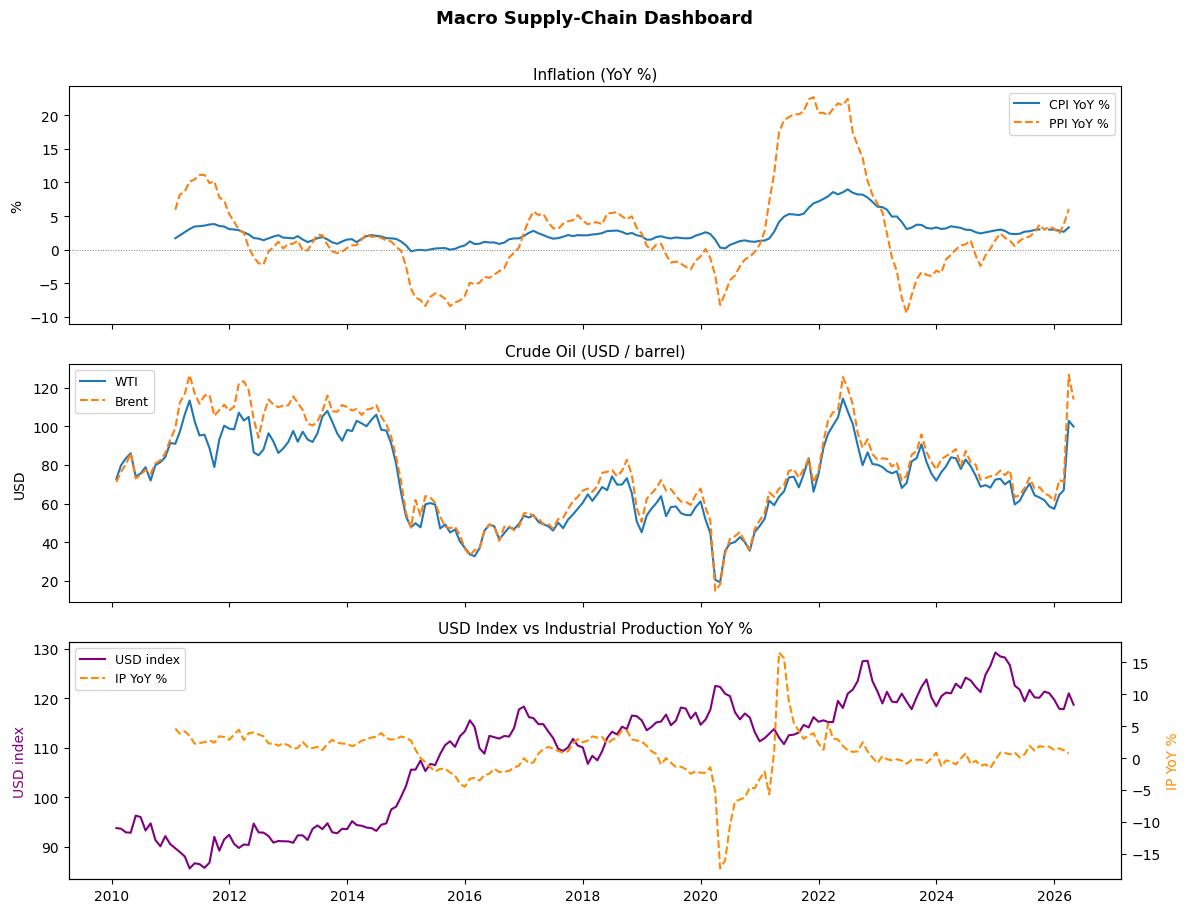

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Inflation
axes[0].plot(snapshot.index, snapshot["cpi_yoy_%"], label="CPI YoY %")
axes[0].plot(snapshot.index, snapshot["ppi_yoy_%"], label="PPI YoY %", linestyle="--")
axes[0].axhline(0, color="grey", linewidth=0.7, linestyle=":")
axes[0].set_title("Inflation (YoY %)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylabel("%")

# Energy
axes[1].plot(snapshot.index, snapshot["wti_usd"],   label="WTI")
axes[1].plot(snapshot.index, snapshot["brent_usd"], label="Brent", linestyle="--")
axes[1].set_title("Crude Oil (USD / barrel)", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_ylabel("USD")

# USD + IP
ax2b = axes[2].twinx()
axes[2].plot(snapshot.index, snapshot["usd_index"], label="USD index", color="purple")
ax2b.plot(snapshot.index, snapshot["ip_yoy_%"], label="IP YoY %", color="darkorange", linestyle="--")
axes[2].set_title("USD Index vs Industrial Production YoY %", fontsize=11)
axes[2].set_ylabel("USD index", color="purple")
ax2b.set_ylabel("IP YoY %", color="darkorange")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Macro Supply-Chain Dashboard", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()